In [1]:
# Import libraries for data handling, visualization and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load the California Housing Dataset from sklearn

housing = fetch_california_housing(as_frame=True)

# Combine features and target variable into a single DataFrame

df = pd.concat(
    [housing.data,
     housing.target.rename("HousePrice")],
    axis=1
)

# Display dataset shape and first few records

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Check dataset information such as data types and null values

print(df.info())

# Check missing values in each column

print("\nMissing Values:")
print(df.isnull().sum())

# Generate statistical summary of the dataset

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.4

In [4]:
# Features (input variables)

X = df.drop("HousePrice", axis=1)

# Target variable (house price)

y = df["HousePrice"]

# Display shapes of feature and target datasets

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [5]:
# Standardize features so all variables have similar scale

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


In [6]:
# Split dataset into 80% training data and 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Display dimensions of training and testing datasets

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [7]:
# Create multiple regression models for comparison

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

In [8]:
# Store evaluation results

results = {}

# Train and evaluate each model

for name, model in models.items():

    # Train model on training data
    model.fit(X_train, y_train)

    # Predict house prices on test data
    predictions = model.predict(X_test)

    # Calculate evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Save results
    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    }

# Convert results into DataFrame

results_df = pd.DataFrame(results).T

# Display model comparison table

results_df

,RMSE,MAE,R2 Score
Linear Regression,0.745581,0.533200,0.575788
Ridge Regression,0.745554,0.533193,0.575819
Decision Tree,0.724234,0.522259,0.599732


In [9]:
# Identify model with highest R² Score

best_model_name = results_df["R2 Score"].idxmax()

print("Best Model =", best_model_name)

# Store best model for future predictions

best_model = models[best_model_name]

Best Model = Decision Tree


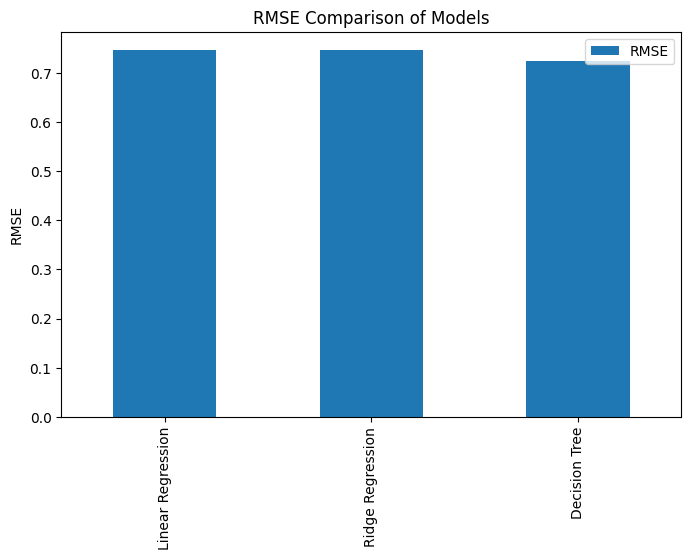

In [10]:
# Plot RMSE values for all models

results_df[["RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("RMSE Comparison of Models")
plt.ylabel("RMSE")
plt.show()

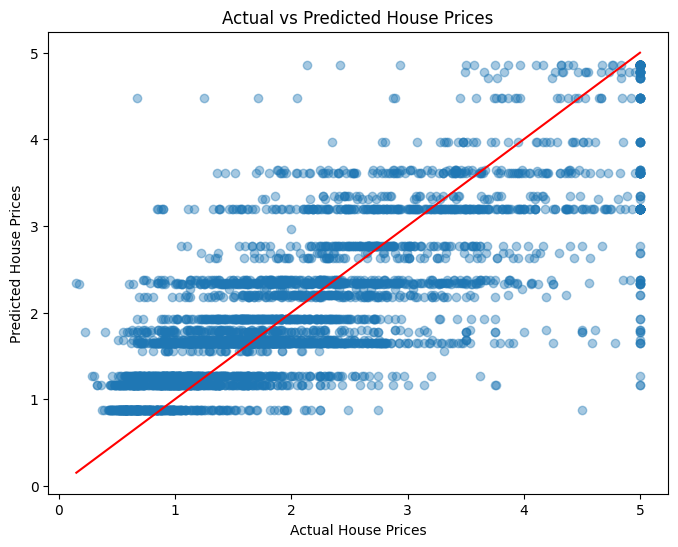

In [11]:
# Generate predictions using best model

y_pred = best_model.predict(X_test)

# Create scatter plot comparing actual and predicted values

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Reference line showing perfect prediction

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [12]:
# Select first house record from dataset

sample_house = X.iloc[[0]]

# Apply same scaling used during training

sample_scaled = scaler.transform(sample_house)

# Predict house price using best model

predicted_price = best_model.predict(sample_scaled)[0]

# Convert value to US Dollars
# California Housing target values are in hundreds of thousands

price_usd = predicted_price * 100000

print("Predicted House Price = ${:,.0f}".format(price_usd))

Predicted House Price = $477,879


In [13]:
# Display complete project summary

print("========== PROJECT SUMMARY ==========")

print("\nDataset Used: California Housing Dataset")

print("\nModels Compared:")
print("- Linear Regression")
print("- Ridge Regression")
print("- Decision Tree Regressor")

print("\nPerformance Comparison:")
print(results_df)

print("\nSelected Best Model:")
print(best_model_name)

print("\nFinal Predicted House Price:")
print("${:,.0f}".format(price_usd))

========== PROJECT SUMMARY ==========

Dataset Used: California Housing Dataset

Models Compared:
- Linear Regression
- Ridge Regression
- Decision Tree Regressor

Performance Comparison:
                       RMSE       MAE  R2 Score
Linear Regression  0.745581  0.533200  0.575788
Ridge Regression   0.745554  0.533193  0.575819
Decision Tree      0.724234  0.522259  0.599732

Selected Best Model:
Decision Tree

Final Predicted House Price:
$477,879
